In [ ]:
import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
from google.colab import drive

# Path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/validation_dataset.zip'

# Extract path (where you want to extract the contents)
extract_path = '/content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
# Define the paths for the training and validation data
train_path = '/content/train_dataset'
val_path = '/content/validation_dataset'
test_path = '/content/test_dataset'

# **CNN**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
import os

# Define the paths for the training and validation data
train_path = '/content/train_dataset'
val_path = '/content/validation_dataset'

batch_size = 64

# Create ImageDataGenerators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, fill_mode='constant', cval=255)

val_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale for validation data

test_datagen = ImageDataGenerator(rescale=1./255)  # Rescale only for test data

train_gen = train_datagen.flow_from_directory(train_path, target_size=(150,150),
                    class_mode='categorical', batch_size=batch_size)

val_gen = val_datagen.flow_from_directory(val_path, target_size=(150,150),
                class_mode='categorical', batch_size=batch_size)

test_gen = test_datagen.flow_from_directory(test_path, target_size=(150, 150),
                                            class_mode='categorical', batch_size=batch_size)


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3), padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compiling the model with additional metrics
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

model.summary()


Found 16000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 75, 75, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_28 (Dropout)        (None, 75, 75, 32)        0         
                                                                 
 conv2d_21 (Conv2D)          (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_21 (MaxPooli  (None, 37, 37, 64)        0         
 ng2D)                                                  

In [ ]:
# Define callbacks
reduce_lr = ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=1)

# Train the model using the categorical labels
history = model.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=[reduce_lr, early_stop])

# Evaluate the model on the validation set
val_loss, val_accuracy, val_precision, val_recall = model.evaluate(val_gen)

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Validation Precision: {val_precision:.4f}')
print(f'Validation Recall: {val_recall:.4f}')


Epoch 1/10
250/250 [==============================] - 48s 163ms/step - loss: 1.1915 - accuracy: 0.5571 - precision: 0.8423 - recall: 0.4306 - val_loss: 0.2289 - val_accuracy: 0.9370 - val_precision: 0.9717 - val_recall: 0.8930 - lr: 0.0010
Epoch 2/10
250/250 [==============================] - 39s 156ms/step - loss: 0.0865 - accuracy: 0.9697 - precision: 0.9731 - recall: 0.9659 - val_loss: 0.0202 - val_accuracy: 0.9890 - val_precision: 0.9900 - val_recall: 0.9890 - lr: 0.0010
Epoch 3/10
250/250 [==============================] - 37s 148ms/step - loss: 0.0343 - accuracy: 0.9859 - precision: 0.9865 - recall: 0.9853 - val_loss: 0.0336 - val_accuracy: 0.9840 - val_precision: 0.9845 - val_recall: 0.9830 - lr: 0.0010
Epoch 4/10
250/250 [==============================] - 40s 158ms/step - loss: 0.0289 - accuracy: 0.9881 - precision: 0.9884 - recall: 0.9876 - val_loss: 0.0159 - val_accuracy: 0.9890 - val_precision: 0.9940 - val_recall: 0.9860 - lr: 0.0010
Epoch 5/10
250/250 [====================

In [ ]:
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    class_mode='categorical',
    batch_size=batch_size)


evaluation_results = model.evaluate(test_gen, steps=test_gen.samples // batch_size)

print('Test Loss:', evaluation_results[0])
print('Test Accuracy:', evaluation_results[1])
print('Test Precision:', evaluation_results[2])
print('Test Recall:', evaluation_results[3])


Found 2000 images belonging to 10 classes.
31/31 [==============================] - 3s 110ms/step - loss: 0.0128 - accuracy: 0.9929 - precision: 0.9929 - recall: 0.9929
Test Loss: 0.012835155241191387
Test Accuracy: 0.992943525314331
Test Precision: 0.992943525314331
Test Recall: 0.992943525314331


In [ ]:
val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=(150,150),
    class_mode='categorical',
    batch_size=batch_size)

evaluation_results = model.evaluate(val_gen, steps=val_gen.samples // batch_size)

print('Validaion Loss:', evaluation_results[0])
print('Validaion Accuracy:', evaluation_results[1])
print('Validaion Precision:', evaluation_results[2])
print('Validaion Recall:', evaluation_results[3])


Found 2000 images belonging to 10 classes.
31/31 [==============================] - 4s 137ms/step - loss: 0.0165 - accuracy: 0.9879 - precision: 0.9879 - recall: 0.9879
Validaion Loss: 0.01653689704835415
Validaion Accuracy: 0.9879032373428345
Validaion Precision: 0.9879032373428345
Validaion Recall: 0.9879032373428345


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
def plot_training_history(history):
    # Setup figure and axes
    plt.figure(figsize=(12, 6))

    # Subplot for accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Subplot for loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

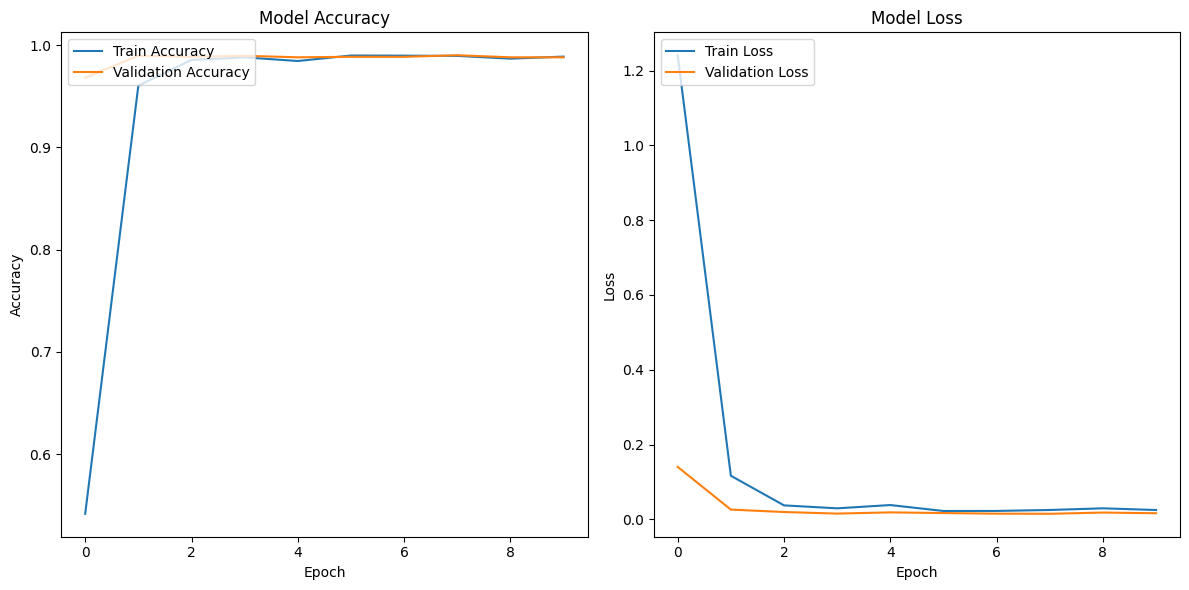

In [ ]:
# Assuming 'history' is defined and contains the history of a fitting model
plot_training_history(history)